In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix
)

import tensorflow as tf

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    DepthwiseConv2D,
    SeparableConv2D,
    BatchNormalization,
    Activation,
    AveragePooling2D,
    Dropout,
    Flatten,
    Dense
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

from tensorflow.keras.constraints import max_norm

In [3]:
FS = 250

CHANNELS = [
    "FZ",
    "C3",
    "CZ",
    "C4"
]

N_CHANNELS = len(CHANNELS)

RANDOM_STATE = 42

MANIFEST_PATH = Path(
    "../../data/Processed/final_clean_manifest.csv"
)

FINAL_DATA_DIR = Path(
    "../../data/Processed/final_clean_trials"
)

## Load final manifest

In [4]:
manifest = pd.read_csv(MANIFEST_PATH)

print("Total trials:", len(manifest))
print()
print(manifest["label"].value_counts())

display(manifest.head())

Total trials: 1935

label
right    971
left     964
Name: count, dtype: int64


,trial_id,file_path,label
0,1,..\..\data\Processed\final_clean_trials\cellul...,left
1,2,..\..\data\Processed\final_clean_trials\cellul...,right
2,3,..\..\data\Processed\final_clean_trials\cellul...,left
3,4,..\..\data\Processed\final_clean_trials\cellul...,left
4,5,..\..\data\Processed\final_clean_trials\cellul...,left


In [5]:
print("Unique trial IDs:", manifest["trial_id"].is_unique)

print(
    "Labels:",
    manifest["label"].unique()
)

assert manifest["trial_id"].is_unique

assert set(
    manifest["label"].str.lower().unique()
) == {"left", "right"}

print("Dataset checks passed.")

Unique trial IDs: True
Labels: <StringArray>
['left', 'right']
Length: 2, dtype: str
Dataset checks passed.


## Load EEG trials

In [6]:
def load_eeg_data(manifest):
    X = []
    y = []

    for _, row in manifest.iterrows():

        trial_id = int(row["trial_id"])

        file_path = (
            FINAL_DATA_DIR
            / f"cellula_MI_data_{trial_id}.csv"
        )

        df = pd.read_csv(file_path)

        trial = df[CHANNELS].values.T

        X.append(trial)
        y.append(row["label"].lower())

    return np.array(X), np.array(y)


X, y_text = load_eeg_data(manifest)

print("X shape:", X.shape)
print("Labels:", np.unique(y_text, return_counts=True))

X shape: (1935, 4, 2500)
Labels: (array(['left', 'right'], dtype='<U5'), array([964, 971]))


## Encode labels

In [7]:
y = pd.Series(y_text).map({
    "left": 0,
    "right": 1
}).to_numpy()

print(
    np.unique(
        y,
        return_counts=True
    )
)

(array([0, 1]), array([964, 971]))


## Split into train, validation, test

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    stratify=y_train,
    random_state=RANDOM_STATE
)

print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)

print()
print(
    "Train labels:",
    np.unique(y_train, return_counts=True)
)

Train: (1238, 4, 2500)
Val  : (310, 4, 2500)
Test : (387, 4, 2500)

Train labels: (array([0, 1]), array([617, 621]))


## Normalization (train only)

In [9]:
train_mean = X_train.mean(
    axis=(0, 2),
    keepdims=True
)

train_std = X_train.std(
    axis=(0, 2),
    keepdims=True
)

train_std = np.where(
    train_std == 0,
    1,
    train_std
)

X_train_norm = (
    X_train - train_mean
) / train_std

X_val_norm = (
    X_val - train_mean
) / train_std

X_test_norm = (
    X_test - train_mean
) / train_std

In [10]:
print(
    "Training mean:",
    X_train_norm.mean()
)

print(
    "Training std:",
    X_train_norm.std()
)

print(
    "NaNs:",
    np.isnan(X_train_norm).sum()
)

print(
    "Inf:",
    np.isinf(X_train_norm).sum()
)

Training mean: 1.763156126215693e-18
Training std: 1.0
NaNs: 0
Inf: 0


## Add EEGNet's final dimension

In [11]:
X_train_net = X_train_norm[..., np.newaxis]
X_val_net = X_val_norm[..., np.newaxis]
X_test_net = X_test_norm[..., np.newaxis]

print("Train:", X_train_net.shape)
print("Val  :", X_val_net.shape)
print("Test :", X_test_net.shape)

Train: (1238, 4, 2500, 1)
Val  : (310, 4, 2500, 1)
Test : (387, 4, 2500, 1)


## Build EEGNet

In [12]:
def build_eegnet(
    n_channels=4,
    n_samples=2500,
    F1=8,
    D=2,
    F2=16,
    dropout_rate=0.5
):

    inputs = Input(
        shape=(
            n_channels,
            n_samples,
            1
        )
    )

    # Learn temporal / frequency patterns
    x = Conv2D(
        F1,
        (1, 64),
        padding="same",
        use_bias=False
    )(inputs)

    x = BatchNormalization()(x)

    # Learn relationships between EEG channels
    x = DepthwiseConv2D(
        (n_channels, 1),
        depth_multiplier=D,
        use_bias=False,
        depthwise_constraint=max_norm(1.0)
    )(x)

    x = BatchNormalization()(x)

    x = Activation("elu")(x)

    x = AveragePooling2D(
        (1, 4)
    )(x)

    x = Dropout(
        dropout_rate
    )(x)

    # Learn more detailed temporal patterns
    x = SeparableConv2D(
        F2,
        (1, 16),
        padding="same",
        use_bias=False
    )(x)

    x = BatchNormalization()(x)

    x = Activation("elu")(x)

    x = AveragePooling2D(
        (1, 8)
    )(x)

    x = Dropout(
        dropout_rate
    )(x)

    x = Flatten()(x)

    outputs = Dense(
        1,
        activation="sigmoid",
        kernel_constraint=max_norm(0.25)
    )(x)

    model = Model(
        inputs=inputs,
        outputs=outputs
    )

    return model

In [13]:
tf.keras.utils.set_random_seed(
    RANDOM_STATE
)

model = build_eegnet(
    n_channels=N_CHANNELS,
    n_samples=X_train_net.shape[2]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 4, 2500, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 4, 2500, 8)     │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 4, 2500, 8)     │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d                │ (None, 1, 2500, 16)    │            64 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1, 2500, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 1, 2500, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 1, 625, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 625, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d                │ (None, 1, 625, 16)     │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 1, 625, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1, 625, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 1, 78, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1, 78, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1248)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,249 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,497 (9.75 KB)

 Trainable params: 2,417 (9.44 KB)

 Non-trainable params: 80 (320.00 B)

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## Callbacks

In [15]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=5,
    min_lr=1e-6
)

## Training 

In [16]:
history = model.fit(
    X_train_net,
    y_train,

    validation_data=(
        X_val_net,
        y_val
    ),

    epochs=100,
    batch_size=32,

    callbacks=[
        early_stopping,
        reduce_lr
    ],

    verbose=1
)

Epoch 1/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 5s 75ms/step - accuracy: 0.5032 - loss: 0.6965 - val_accuracy: 0.4742 - val_loss: 0.6936 - learning_rate: 0.0010
Epoch 2/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.5258 - loss: 0.6884 - val_accuracy: 0.4516 - val_loss: 0.6939 - learning_rate: 0.0010
Epoch 3/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 2s 63ms/step - accuracy: 0.5452 - loss: 0.6821 - val_accuracy: 0.4839 - val_loss: 0.6941 - learning_rate: 0.0010
Epoch 4/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.5444 - loss: 0.6814 - val_accuracy: 0.5097 - val_loss: 0.6947 - learning_rate: 0.0010
Epoch 5/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.5630 - loss: 0.6757 - val_accuracy: 0.4710 - val_loss: 0.6955 - learning_rate: 0.0010
Epoch 6/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.5533 - loss: 0.6777 - val_accuracy: 0.4935 - val_loss: 0.6985 - learning_rate: 0.0010
Epoch 7/100
39/39 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.5897 - loss: 0.6696 - 

## Plots

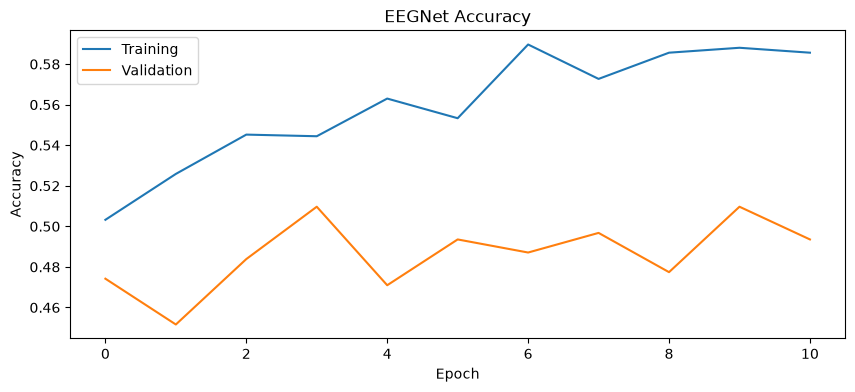

In [17]:
plt.figure(figsize=(10, 4))

plt.plot(
    history.history["accuracy"],
    label="Training"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("EEGNet Accuracy")
plt.legend()

plt.show()

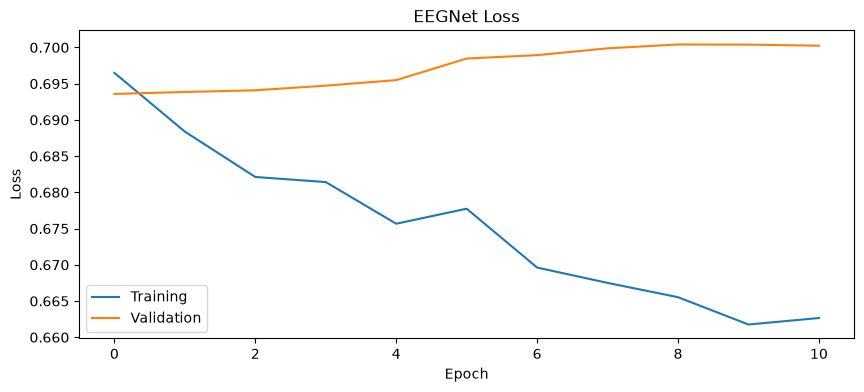

In [18]:
plt.figure(figsize=(10, 4))

plt.plot(
    history.history["loss"],
    label="Training"
)

plt.plot(
    history.history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("EEGNet Loss")
plt.legend()

plt.show()

In [19]:
val_loss, val_accuracy = model.evaluate(
    X_val_net,
    y_val,
    verbose=0
)

print(
    f"Validation accuracy: "
    f"{val_accuracy * 100:.2f}%"
)

Validation accuracy: 47.42%


In [20]:
y_prob = model.predict(
    X_test_net
).ravel()

y_pred = (
    y_prob >= 0.5
).astype(int)

13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


In [21]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

balanced_accuracy = balanced_accuracy_score(
    y_test,
    y_pred
)

print(
    f"Test accuracy: "
    f"{accuracy * 100:.2f}%"
)

print(
    f"Balanced accuracy: "
    f"{balanced_accuracy * 100:.2f}%"
)

Test accuracy: 50.39%
Balanced accuracy: 50.32%


In [22]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "LEFT",
            "RIGHT"
        ]
    )
)

              precision    recall  f1-score   support

        LEFT       0.51      0.26      0.34       193
       RIGHT       0.50      0.75      0.60       194

    accuracy                           0.50       387
   macro avg       0.50      0.50      0.47       387
weighted avg       0.50      0.50      0.47       387



In [23]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[ 50 143]
 [ 49 145]]


In [24]:
majority_accuracy = max(
    np.mean(y_test == 0),
    np.mean(y_test == 1)
)

print(
    f"Majority baseline: "
    f"{majority_accuracy * 100:.2f}%"
)

print(
    f"EEGNet balanced accuracy: "
    f"{balanced_accuracy * 100:.2f}%"
)

Majority baseline: 50.13%
EEGNet balanced accuracy: 50.32%


### EEGNet Full-Trial Baseline

- EEGNet was trained using the full 10-second cleaned EEG trials.
- Training accuracy increased to about 59%, while validation accuracy remained near 50%.
- Validation loss increased while training loss decreased, indicating overfitting.
- Final balanced test accuracy was **50.32%**, approximately equal to the **50.13% majority baseline**.
- The model strongly favored the RIGHT class.
- Therefore, full-trial EEGNet does not currently extract useful LEFT/RIGHT information.
- The next experiment will test shorter temporal windows after splitting trials into train/validation/test sets.